In [50]:
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB

In [32]:
dataset = pd.read_csv("diabetes_pima.csv")
dataset.head(5)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72.0,35,169.5,33.6,0.627,50,1
1,1,85,66.0,29,102.5,26.6,0.351,31,0
2,8,183,64.0,32,169.5,23.3,0.672,32,1
3,1,89,66.0,23,94.0,28.1,0.167,21,0
4,0,137,40.0,35,168.0,43.1,2.288,33,1


In [8]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    float64
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    float64
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(4), int64(5)
memory usage: 54.1 KB


In [12]:
dataset.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [13]:
dataset.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.677083,72.389323,29.089844,141.753906,32.434635,0.471876,33.240885,0.348958
std,3.369578,30.464161,12.106039,8.890820,89.100847,6.880498,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,25.000000,102.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,28.000000,102.500000,32.050000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,169.500000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


<function matplotlib.pyplot.show(close=None, block=None)>

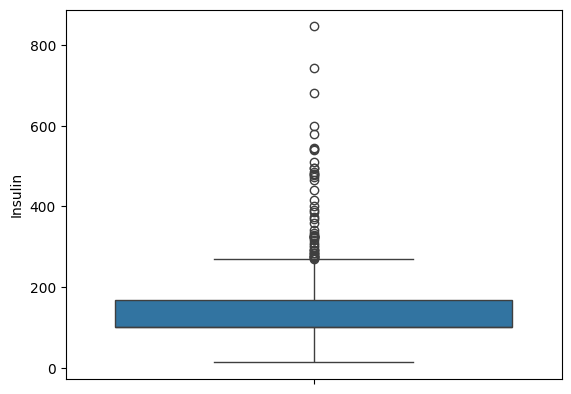

In [16]:
sns.boxplot(dataset["Insulin"])
plt.show

In [17]:
q1 = dataset["Insulin"].quantile(0.25)
q3 = dataset["Insulin"].quantile(0.75)
iqr = q3-q1
min_range = q1-(1.5*iqr)
max_range = q3+(1.5*iqr)

min_range, max_range

(2.0, 270.0)

In [77]:
dataset = dataset[dataset["Insulin"] <= max_range]
dataset

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,Glucose_SS,BloodPressure_SS,SkinThickness_SS,BMI_SS
0,6,148,72.0,35,169.5,33.6,0.627,50,1,0.864625,-0.032180,0.665181,0.169483
1,1,85,66.0,29,102.5,26.6,0.351,31,0,-1.204727,-0.528124,-0.010112,-0.848549
2,8,183,64.0,32,169.5,23.3,0.672,32,1,2.014265,-0.693438,0.327535,-1.328478
3,1,89,66.0,23,94.0,28.1,0.167,21,0,-1.073339,-0.528124,-0.685405,-0.630399
4,0,137,40.0,35,168.0,43.1,2.288,33,1,0.503310,-2.677212,0.665181,1.551096
...,...,...,...,...,...,...,...,...,...,...,...,...,...
763,10,101,76.0,48,180.0,32.9,0.171,63,0,-0.679177,0.298449,2.128317,0.067679
764,2,122,70.0,27,102.5,36.8,0.340,27,0,0.010607,-0.197495,-0.235210,0.634868
765,5,121,72.0,23,112.0,26.2,0.245,30,0,-0.022240,-0.032180,-0.685405,-0.906722
766,1,126,60.0,32,169.5,30.1,0.349,47,1,0.141994,-1.024067,0.327535,-0.339533


<function matplotlib.pyplot.show(close=None, block=None)>

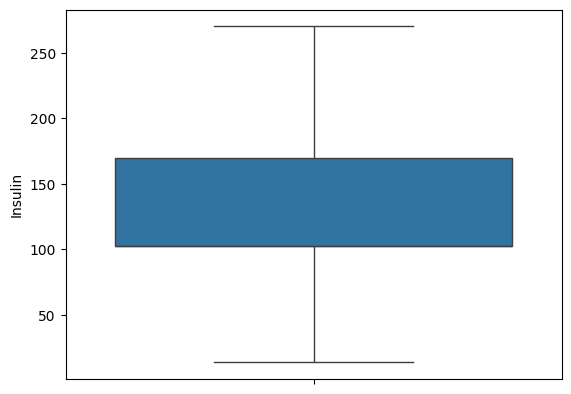

In [78]:
sns.boxplot(dataset["Insulin"])
plt.show

In [25]:
ss = StandardScaler()
ss.fit(dataset[["Insulin"]])

,copy,True
,with_mean,True
,with_std,True


In [29]:
dataset["Insulin_SS"]= ss.transform(dataset[["Insulin"]])

In [63]:
ss.fit(dataset[["Glucose"]])

,copy,True
,with_mean,True
,with_std,True


In [65]:
dataset["Glucose_SS"]= ss.transform(dataset[["Glucose"]])

In [66]:
ss.fit(dataset[["BloodPressure"]])

,copy,True
,with_mean,True
,with_std,True


In [67]:
dataset["BloodPressure_SS"]= ss.transform(dataset[["BloodPressure"]])

In [72]:
ss.fit(dataset[["SkinThickness"]])

,copy,True
,with_mean,True
,with_std,True


In [73]:
dataset["SkinThickness_SS"] = ss.transform(dataset[["SkinThickness"]])

In [75]:
ss.fit(dataset[["BMI"]])

,copy,True
,with_mean,True
,with_std,True


In [76]:
dataset["BMI_SS"] = ss.transform(dataset[["BMI"]])

In [79]:
ss.fit(dataset[["DiabetesPedigreeFunction"]])

,copy,True
,with_mean,True
,with_std,True


In [84]:
dataset.value_counts()

Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin  BMI   DiabetesPedigreeFunction  Age  Outcome  Glucose_SS  BloodPressure_SS  SkinThickness_SS  BMI_SS     DiabetesPedigreeFunction_SS
0            57       60.0           27             102.5    21.7   0.847178                 67   0        -2.124438   -1.024067         -0.235210         -1.561171   1.198527                      1
5            126      78.0           27             22.0     29.6  -0.079909                 40   0         0.141994    0.463763         -0.235210         -0.412250  -1.705158                      1
             103      108.0          37             102.5    39.2  -0.499604                 65   0        -0.613483    2.943480          0.890279          0.983908  -3.019664                      1
             104      74.0           27             102.5    28.8  -0.975676                 48   0        -0.580636    0.133134         -0.235210         -0.528596  -4.510746                      1
          

In [99]:
dataset

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,Glucose_SS,BloodPressure_SS,SkinThickness_SS,BMI_SS,DiabetesPedigreeFunction_SS
0,6,148,72.0,35,169.5,33.6,0.508917,50,1,0.864625,-0.032180,0.665181,0.169483,0.139075
1,1,85,66.0,29,102.5,26.6,-0.355529,31,0,-1.204727,-0.528124,-0.010112,-0.848549,-2.568416
2,8,183,64.0,32,169.5,23.3,0.649859,32,1,2.014265,-0.693438,0.327535,-1.328478,0.580513
3,1,89,66.0,23,94.0,28.1,-0.931827,21,0,-1.073339,-0.528124,-0.685405,-0.630399,-4.373409
4,0,137,40.0,35,168.0,43.1,5.711255,33,1,0.503310,-2.677212,0.665181,1.551096,16.433065
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
763,10,101,76.0,48,180.0,32.9,-0.919299,63,0,-0.679177,0.298449,2.128317,0.067679,-4.334170
764,2,122,70.0,27,102.5,36.8,-0.389982,27,0,0.010607,-0.197495,-0.235210,0.634868,-2.676323
765,5,121,72.0,23,112.0,26.2,-0.687527,30,0,-0.022240,-0.032180,-0.685405,-0.906722,-3.608249
766,1,126,60.0,32,169.5,30.1,-0.361793,47,1,0.141994,-1.024067,0.327535,-0.339533,-2.588035


In [86]:
x = dataset.drop("Outcome", axis=1)
y = dataset["Outcome"]

In [87]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [88]:
lr = LogisticRegression()
lr.fit(x_train, y_train)

C:\Users\Admin\AppData\Local\miniconda3\envs\ml_final\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [89]:
lr.score(x_test, y_test)

0.8611111111111112

In [100]:
lr.predict([[10,101,76.0,48,180.0,32.9,-0.919299,63,-0.679177,0.298449,2.128317,0.067679,-4.334170]])

C:\Users\Admin\AppData\Local\miniconda3\envs\ml_final\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


array([1], dtype=int64)

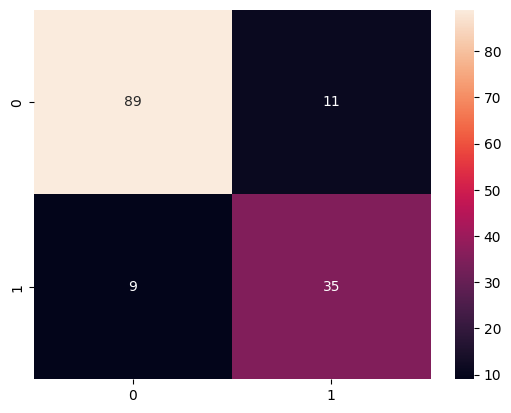

In [101]:
cf = confusion_matrix(y_test, lr.predict(x_test))
sns.heatmap(cf, annot=True)
plt.show()

In [92]:
ps = precision_score(y_test, lr.predict(x_test))*100
ps

76.08695652173914

In [93]:
rs = recall_score(y_test, lr.predict(x_test))*100
rs

79.54545454545455

In [94]:
f1s = f1_score(y_test, lr.predict(x_test))*100
f1s

77.77777777777779

In [95]:
gnb = GaussianNB()
gnb.fit(x_train, y_train)
gnb.score(x_test, y_test)*100,  gnb.score(x_train, y_train)*100

(81.94444444444444, 79.75567190226876)

In [103]:
# mnb = MultinomialNB()
# mnb.fit(x_train, y_train)
# mnb.score(x_test, y_test)*100,  mnb.score(x_train, y_train)*100     NOT considered because it got some neagtive vlaues too in dataset, so Multinomial wont work here.


In [104]:
bnb = BernoulliNB()
bnb.fit(x_train, y_train)
bnb.score(x_test, y_test)*100, bnb.score(x_train, y_train)*100

(80.55555555555556, 78.70855148342059)